**Задача:** сравнить несколько LLM по качеству классификации русских новостей (zero-shot). Интересно посмотреть сравнение результата небольших LLM по сравнению с BERT-моделями, которые использовал в одном из предыдущих заданий

**Датасет:** [data-silence/rus_news_classifier](https://huggingface.co/datasets/data-silence/rus_news_classifier) — 11 классов, русские новости 2019–2024.

**Модели:**
- `mlx-community/Qwen2.5-1.5B-Instruct-4bit`
- `mlx-community/gemma-2-2b-it-4bit`
- `HuggingFaceTB/SmolLM2-1.7B-Instruct-Q8-ml`

**Метрики:** Accuracy, Precision, Recall, F1, Confusion Matrix, Semantic Similarity, время генерации, длина ответа.

In [1]:
%pip install mlx-lm datasets scikit-learn sentence-transformers seaborn matplotlib pandas tqdm


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from mlx_lm import load, generate
from tqdm import tqdm

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

In [ ]:
# Загрузка датасета
LABEL_NAMES = [
    'climate', 'conflicts', 'culture', 'economy', 'gloss',
    'health', 'politics', 'science', 'society', 'sports', 'travel'
]

dataset = load_dataset('data-silence/rus_news_classifier', split='test')
print(f'Строк в датасете: {len(dataset)}')
print(f'Столбцы: {dataset.column_names}')
print(f'\nПример:\n{dataset[0]}')

Строк в датасете: 14383
Столбцы: ['news', 'labels']

Пример:
{'news': 'Ученые Университета Неймегена и Университета Твенте в Нидерландах раскрыли, что сложная внутреклеточная среда может способствовать появлению опасных белковых агрегатов, способствующих болезни Альцгеймера. В этом механизме ключевую роль играют крошечные коацерватные капли, которые собирают потенциально патогенные белки на своей поверхности. Об этом сообщается в статье, опубликованной в журнале Science Advances. Известно, что во внутриклеточной среде в результате разделения жидких фаз образуются коацерватные капли или немембранные органеллы (НМО) — жидкообразные капли, состоящие из белков и нуклеиновых кислот. К таким органеллам относятся, например, ядрышки, тельца Кахаля в ядре и стрессовые гранулы в цитоплазме. Между немембранными органеллами и окружающим раствором отсутствует физический барьер, что позволяет им обмениваться различными компонентами и быстро реагировать на внешние изменения. Показано, что разделение 

In [6]:
# Делаем сбалансированную сокращенную выборку
N_PER_CLASS = 15 

df_full = dataset.to_pandas()

df_sample = (
    df_full.groupby('labels', group_keys=False)
    .apply(lambda x: x.sample(n=min(N_PER_CLASS, len(x)), random_state=SEED))
    .reset_index(drop=True)
)

df_sample['label_name'] = df_sample['labels'].apply(lambda i: LABEL_NAMES[i])

print(f'Размер выборки: {len(df_sample)}')
print(df_sample['label_name'].value_counts().sort_index())

Размер выборки: 165
label_name
climate      15
conflicts    15
culture      15
economy      15
gloss        15
health       15
politics     15
science      15
society      15
sports       15
travel       15
Name: count, dtype: int64


In [19]:
CATEGORIES = ', '.join(LABEL_NAMES)

SYSTEM_PROMPT = (
    'Ты классификатор новостей. '
    'Твоя задача - определить категорию новости. '
    f'Доступные категории: {CATEGORIES}. '
    'Ответь строго одним словом - только название категории на английском языке, без пояснений.'
)

MODELS = {
    'SmolLM2-1.7B': 'HuggingFaceTB/SmolLM2-1.7B-Instruct-Q8-mlx',
    'Qwen2.5-1.5B': 'mlx-community/Qwen2.5-1.5B-Instruct-4bit',
    'Gemma-2-2B':   'mlx-community/gemma-2-2b-it-4bit',
}

def parse_label(response: str) -> str:
    response = response.strip().lower()
    for label in LABEL_NAMES:
        if label in response:
            return label
    return 'unknown'


# Проверка парсера
print(parse_label('  Politics '))                       # politics
print(parse_label('Это экономическая новость economy')) # economy
print(parse_label('не знаю'))                           # unknown

politics
economy
unknown


In [14]:
def build_prompt(tokenizer, supports_system: bool, user_content: str) -> str:
    if supports_system:
        messages = [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user', 'content': user_content},
        ]
    else:
        messages = [
            {'role': 'user', 'content': f'{SYSTEM_PROMPT}\n\n{user_content}'},
        ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


def check_system_support(tokenizer) -> bool:
    try:
        tokenizer.apply_chat_template(
            [{'role': 'system', 'content': ''}, {'role': 'user', 'content': ''}],
            tokenize=False, add_generation_prompt=False
        )
        return True
    except Exception:
        return False


def run_model(model_key: str, model_path: str, texts: list) -> dict:
    print(f"\n{'='*60}")
    print(f'Загружаем модель: {model_key}')
    model, tokenizer = load(model_path)

    supports_system = check_system_support(tokenizer)
    print(f'System role: {"да" if supports_system else "нет"}')

    raw_responses, pred_labels, gen_times, response_lengths = [], [], [], []

    for text in tqdm(texts, desc=model_key):
        prompt = build_prompt(tokenizer, supports_system, f'Новость: {text[:1000]}')

        t0 = time.time()
        response = generate(model, tokenizer, prompt=prompt, max_tokens=10, verbose=False)
        elapsed = time.time() - t0

        raw_responses.append(response)
        pred_labels.append(parse_label(response))
        gen_times.append(elapsed)
        response_lengths.append(len(tokenizer.encode(response)))

    del model  # освобождаем память перед следующей моделью

    return {
        'raw_responses': raw_responses,
        'pred_labels': pred_labels,
        'gen_times': gen_times,
        'response_lengths': response_lengths,
    }

In [20]:
texts = df_sample['news'].tolist()
true_labels = df_sample['label_name'].tolist()

results = {}
for model_key, model_path in MODELS.items():
    results[model_key] = run_model(model_key, model_path, texts)

print('\nИнференс завершён.')


Загружаем модель: SmolLM2-1.7B


Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.82G [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...


Загружаем модель: Gemma-2-2B


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

System role: нет


Gemma-2-2B: 100%|██████████| 165/165 [01:26<00:00,  1.91it/s]


Инференс завершён.


## Метрики классификации

In [22]:
def classification_metrics(true: list, pred: list) -> dict:
    return {
        'accuracy': accuracy_score(true, pred),
        'precision_macro': precision_score(true, pred, average='macro', labels=LABEL_NAMES, zero_division=0),
        'recall_macro': recall_score(true, pred, average='macro', labels=LABEL_NAMES, zero_division=0),
        'f1_macro': f1_score(true, pred, average='macro', labels=LABEL_NAMES, zero_division=0),
        'f1_weighted': f1_score(true, pred, average='weighted', labels=LABEL_NAMES, zero_division=0),
    }


metrics_table = {}
for model_key, res in results.items():
    pred = res['pred_labels']
    m = classification_metrics(true_labels, pred)
    m['unknown_rate'] = pred.count('unknown') / len(pred)
    m['avg_gen_time_s'] = np.mean(res['gen_times'])
    m['avg_response_len'] = np.mean(res['response_lengths'])
    metrics_table[model_key] = m

df_metrics = pd.DataFrame(metrics_table).T.round(4)
print(df_metrics.to_string())

              accuracy  precision_macro  recall_macro  f1_macro  f1_weighted  unknown_rate  avg_gen_time_s  avg_response_len
SmolLM2-1.7B    0.2121           0.3845        0.2121    0.1852       0.1852        0.0788          0.6250            1.3818
Qwen2.5-1.5B    0.4182           0.5740        0.4182    0.4367       0.4367        0.1212          0.3374            1.4061
Gemma-2-2B      0.5091           0.6406        0.5091    0.4970       0.4970        0.0364          0.5241            3.0000


## Semantic Similarity

Сравниваем эмбеддинги предсказанной и истинной метки. Позволяет оценить, насколько «семантически близко» ошиблась модель (например, `politics` vs `conflicts` ближе, чем `politics` vs `sports`).

In [23]:
print('Загружаем sentence-transformer...')
embedder = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')


def semantic_similarity_score(true: list, pred: list) -> float:
    pred_clean = [p if p in LABEL_NAMES else LABEL_NAMES[0] for p in pred]
    true_emb = embedder.encode(true, normalize_embeddings=True)
    pred_emb = embedder.encode(pred_clean, normalize_embeddings=True)
    sims = [cosine_similarity([t], [p])[0][0] for t, p in zip(true_emb, pred_emb)]
    return float(np.mean(sims))


for model_key, res in results.items():
    sim = semantic_similarity_score(true_labels, res['pred_labels'])
    df_metrics.loc[model_key, 'semantic_similarity'] = round(sim, 4)
    print(f'  {model_key}: {sim:.4f}')

Загружаем sentence-transformer...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  SmolLM2-1.7B: 0.5523
  Qwen2.5-1.5B: 0.6514
  Gemma-2-2B: 0.7093


## Итоговая таблица метрик

In [24]:
cols_order = [
    'accuracy', 'precision_macro', 'recall_macro',
    'f1_macro', 'f1_weighted', 'semantic_similarity',
    'unknown_rate', 'avg_gen_time_s', 'avg_response_len',
]
print(df_metrics[cols_order].to_string())

              accuracy  precision_macro  recall_macro  f1_macro  f1_weighted  semantic_similarity  unknown_rate  avg_gen_time_s  avg_response_len
SmolLM2-1.7B    0.2121           0.3845        0.2121    0.1852       0.1852               0.5523        0.0788          0.6250            1.3818
Qwen2.5-1.5B    0.4182           0.5740        0.4182    0.4367       0.4367               0.6514        0.1212          0.3374            1.4061
Gemma-2-2B      0.5091           0.6406        0.5091    0.4970       0.4970               0.7093        0.0364          0.5241            3.0000


## Визуализация

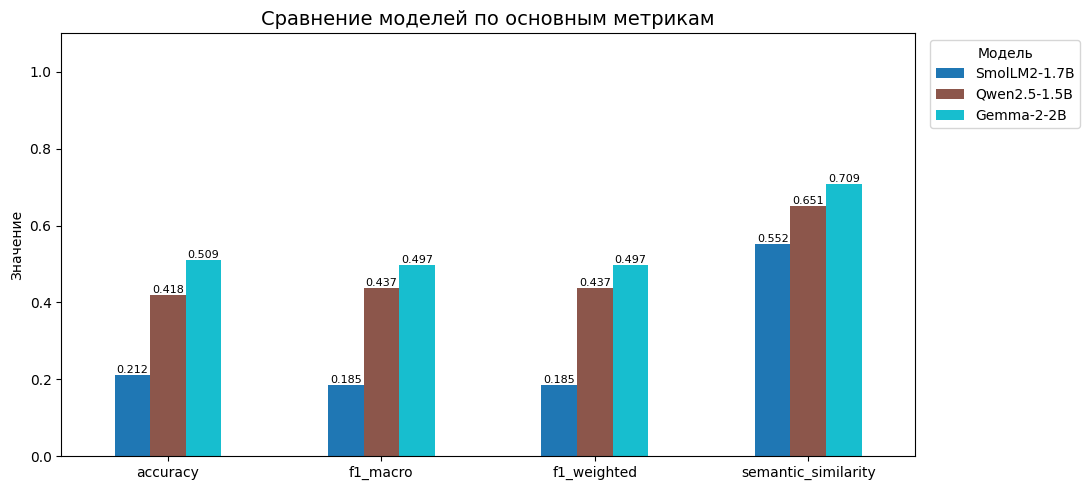

In [25]:
# Сравнение основных метрик
metric_cols = ['accuracy', 'f1_macro', 'f1_weighted', 'semantic_similarity']
df_plot = df_metrics[metric_cols].T

ax = df_plot.plot(kind='bar', figsize=(11, 5), rot=0, colormap='tab10')
ax.set_title('Сравнение моделей по основным метрикам', fontsize=14)
ax.set_ylim(0, 1.1)
ax.legend(title='Модель', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylabel('Значение')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150)
plt.show()

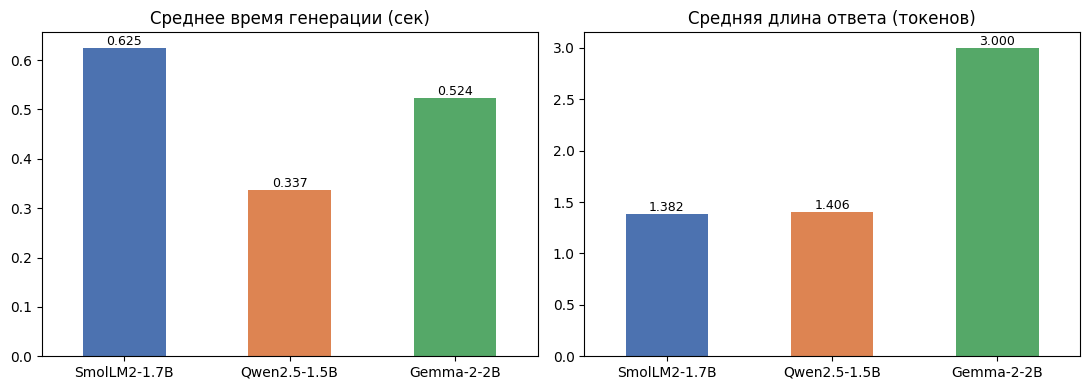

In [26]:
# Время генерации и длина ответа
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, title in zip(
    axes,
    ['avg_gen_time_s', 'avg_response_len'],
    ['Среднее время генерации (сек)', 'Средняя длина ответа (токенов)'],
):
    df_metrics[col].plot(kind='bar', ax=ax, rot=0, color=['#4C72B0', '#DD8452', '#55A868'])
    ax.set_title(title)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=9)

plt.tight_layout()
plt.savefig('time_length_comparison.png', dpi=150)
plt.show()

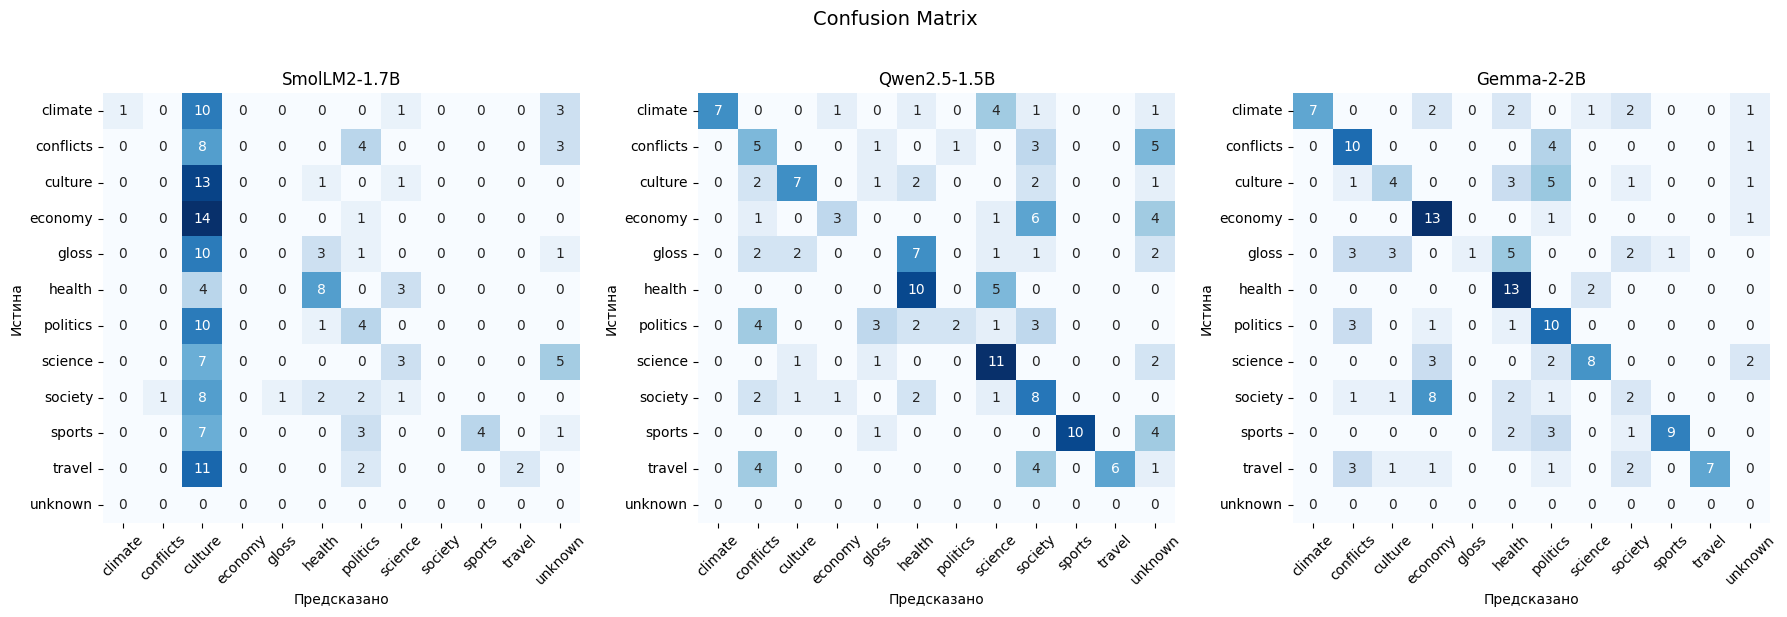

In [27]:
# Confusion Matrix для каждой модели
fig, axes = plt.subplots(1, len(MODELS), figsize=(18, 6))

for ax, (model_key, res) in zip(axes, results.items()):
    pred_clean = [p if p in LABEL_NAMES else 'unknown' for p in res['pred_labels']]
    has_unknown = 'unknown' in pred_clean
    labels_plot = LABEL_NAMES + (['unknown'] if has_unknown else [])
    cm = confusion_matrix(true_labels, pred_clean, labels=labels_plot)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        xticklabels=labels_plot, yticklabels=labels_plot,
        cmap='Blues', cbar=False,
    )
    ax.set_title(model_key, fontsize=12)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истина')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Confusion Matrix', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

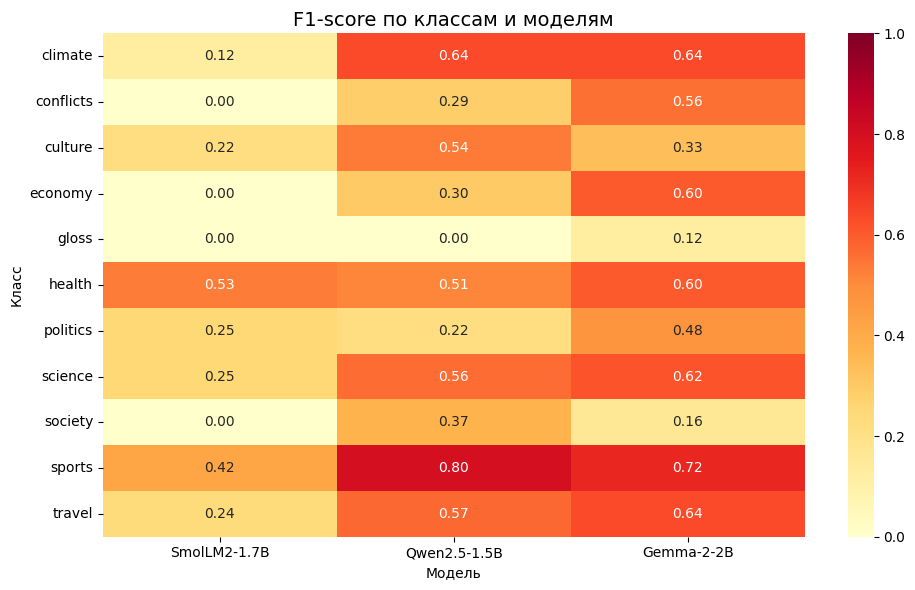

In [28]:
# F1 по классам — heatmap
f1_per_class = {}
for model_key, res in results.items():
    pred = [p if p in LABEL_NAMES else 'unknown' for p in res['pred_labels']]
    f1 = f1_score(true_labels, pred, average=None, labels=LABEL_NAMES, zero_division=0)
    f1_per_class[model_key] = f1

df_f1 = pd.DataFrame(f1_per_class, index=LABEL_NAMES)

plt.figure(figsize=(10, 6))
sns.heatmap(df_f1, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1)
plt.title('F1-score по классам и моделям', fontsize=14)
plt.xlabel('Модель')
plt.ylabel('Класс')
plt.tight_layout()
plt.savefig('f1_per_class_heatmap.png', dpi=150)
plt.show()

## Classification Report (детальный)

In [29]:
for model_key, res in results.items():
    pred = [p if p in LABEL_NAMES else 'unknown' for p in res['pred_labels']]
    print(f"\n{'='*60}")
    print(f'Model: {model_key}')
    print(classification_report(true_labels, pred, labels=LABEL_NAMES, zero_division=0))


Model: SmolLM2-1.7B
              precision    recall  f1-score   support

     climate       1.00      0.07      0.12        15
   conflicts       0.00      0.00      0.00        15
     culture       0.13      0.87      0.22        15
     economy       0.00      0.00      0.00        15
       gloss       0.00      0.00      0.00        15
      health       0.53      0.53      0.53        15
    politics       0.24      0.27      0.25        15
     science       0.33      0.20      0.25        15
     society       0.00      0.00      0.00        15
      sports       1.00      0.27      0.42        15
      travel       1.00      0.13      0.24        15

   micro avg       0.23      0.21      0.22       165
   macro avg       0.38      0.21      0.19       165
weighted avg       0.38      0.21      0.19       165


Model: Qwen2.5-1.5B
              precision    recall  f1-score   support

     climate       1.00      0.47      0.64        15
   conflicts       0.25      0.33   

## Эксперименты с Gemma-2-2B

Все эксперименты проводятся на модели `Gemma-2-2B` как лучшей по метрикам.
Модель загружается один раз и переиспользуется во всех экспериментах.

In [30]:
# Загружаем Gemma один раз для всех экспериментов
GEMMA_PATH = 'mlx-community/gemma-2-2b-it-4bit'
gemma_model, gemma_tokenizer = load(GEMMA_PATH)
gemma_supports_system = check_system_support(gemma_tokenizer)

texts = df_sample['news'].tolist()
true_labels = df_sample['label_name'].tolist()

print(f'Модель загружена. System role: {"да" if gemma_supports_system else "нет"}')

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Модель загружена. System role: нет


### Влияние длины промпта (короткий vs подробный)

Длина короткого промпта: 142 символов
Длина подробного промпта: 754 символов


Подробный: 100%|██████████| 165/165 [01:39<00:00,  1.65it/s]

           accuracy  f1_macro  unknown_rate
Короткий     0.4121    0.4132        0.1879
Подробный    0.5091    0.5155        0.0545


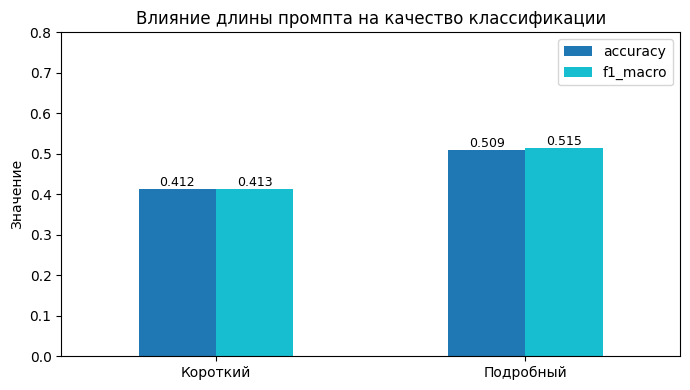

In [31]:
SHORT_PROMPT = f'Категория новости (одно слово на английском): {CATEGORIES}.'

LONG_PROMPT = (
    'Ты — эксперт по классификации русскоязычных новостей. '
    'Твоя задача — внимательно прочитать текст новости и определить, к какой тематической категории она относится. '
    f'Доступные категории: {CATEGORIES}. '
    'Категории означают следующее: '
    'climate — климат и экология, conflicts — войны и конфликты, culture — культура и искусство, '
    'economy — экономика и финансы, gloss — светские новости и знаменитости, health — здоровье и медицина, '
    'politics — политика, science — наука и технологии, society — общество, sports — спорт, travel — путешествия. '
    'Проанализируй тему новости и ответь строго одним словом — только название категории на английском языке, без пояснений и знаков препинания.'
)

print(f'Длина короткого промпта: {len(SHORT_PROMPT)} символов')
print(f'Длина подробного промпта: {len(LONG_PROMPT)} символов')

exp1_results = {}

for prompt_name, system_prompt in [('Короткий', SHORT_PROMPT), ('Подробный', LONG_PROMPT)]:
    preds = []
    for text in tqdm(texts, desc=prompt_name):
        messages = [{'role': 'user', 'content': f'{system_prompt}\n\nНовость: {text[:1000]}'}]
        prompt = gemma_tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        response = generate(gemma_model, gemma_tokenizer, prompt=prompt, max_tokens=10, verbose=False)
        preds.append(parse_label(response))

    m = classification_metrics(true_labels, preds)
    m['unknown_rate'] = preds.count('unknown') / len(preds)
    exp1_results[prompt_name] = m

df_exp1 = pd.DataFrame(exp1_results).T[['accuracy', 'f1_macro', 'unknown_rate']].round(4)
print(df_exp1)

df_exp1[['accuracy', 'f1_macro']].plot(kind='bar', figsize=(7, 4), rot=0, colormap='tab10')
plt.title('Влияние длины промпта на качество классификации')
plt.ylim(0, 0.8)
plt.ylabel('Значение')
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', fontsize=9)
plt.tight_layout()
plt.savefig('exp1_prompt_length.png', dpi=150)
plt.show()

### Zero-shot vs Few-shot (1, 3, 5 примеров)

5-shot: 100%|██████████| 165/165 [02:26<00:00,  1.12it/s]

        accuracy  f1_macro  unknown_rate
0-shot    0.4970    0.4857        0.0485
1-shot    0.5091    0.4789        0.0121
3-shot    0.4848    0.4748        0.0545
5-shot    0.4424    0.4329        0.0485


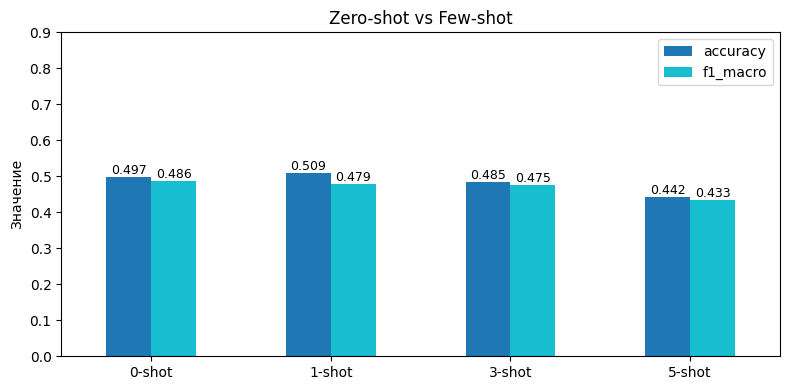

In [32]:
def build_fewshot_prompt(tokenizer, supports_system, text, n_shots, df_pool, labels_pool):
    """Строит few-shot промпт: n_shots примеров из пула, затем тестовый текст."""
    examples = ''
    if n_shots > 0:
        # берём по одному примеру на класс (не пересекаясь с тестовым текстом)
        pool = [(t, l) for t, l in zip(df_pool, labels_pool) if t != text]
        seen_labels = set()
        shots = []
        for t, l in pool:
            if l not in seen_labels:
                shots.append((t, l))
                seen_labels.add(l)
            if len(shots) == n_shots:
                break
        examples = '\n'.join([f'Новость: {t[:300]}\nКатегория: {l}' for t, l in shots])
        examples += '\n\n'

    user_content = f'{examples}Новость: {text[:1000]}\nКатегория:'

    if supports_system:
        messages = [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user', 'content': user_content},
        ]
    else:
        messages = [
            {'role': 'user', 'content': f'{SYSTEM_PROMPT}\n\n{user_content}'},
        ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


exp2_results = {}

for n_shots in [0, 1, 3, 5]:
    preds = []
    for text in tqdm(texts, desc=f'{n_shots}-shot'):
        prompt = build_fewshot_prompt(
            gemma_tokenizer, gemma_supports_system, text, n_shots, texts, true_labels
        )
        response = generate(gemma_model, gemma_tokenizer, prompt=prompt, max_tokens=10, verbose=False)
        preds.append(parse_label(response))

    m = classification_metrics(true_labels, preds)
    m['unknown_rate'] = preds.count('unknown') / len(preds)
    exp2_results[f'{n_shots}-shot'] = m

df_exp2 = pd.DataFrame(exp2_results).T[['accuracy', 'f1_macro', 'unknown_rate']].round(4)
print(df_exp2)

df_exp2[['accuracy', 'f1_macro']].plot(kind='bar', figsize=(8, 4), rot=0, colormap='tab10')
plt.title('Zero-shot vs Few-shot')
plt.ylim(0, 0.9)
plt.ylabel('Значение')
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', fontsize=9)
plt.tight_layout()
plt.savefig('exp2_fewshot.png', dpi=150)
plt.show()

### Анализ типичных ошибок

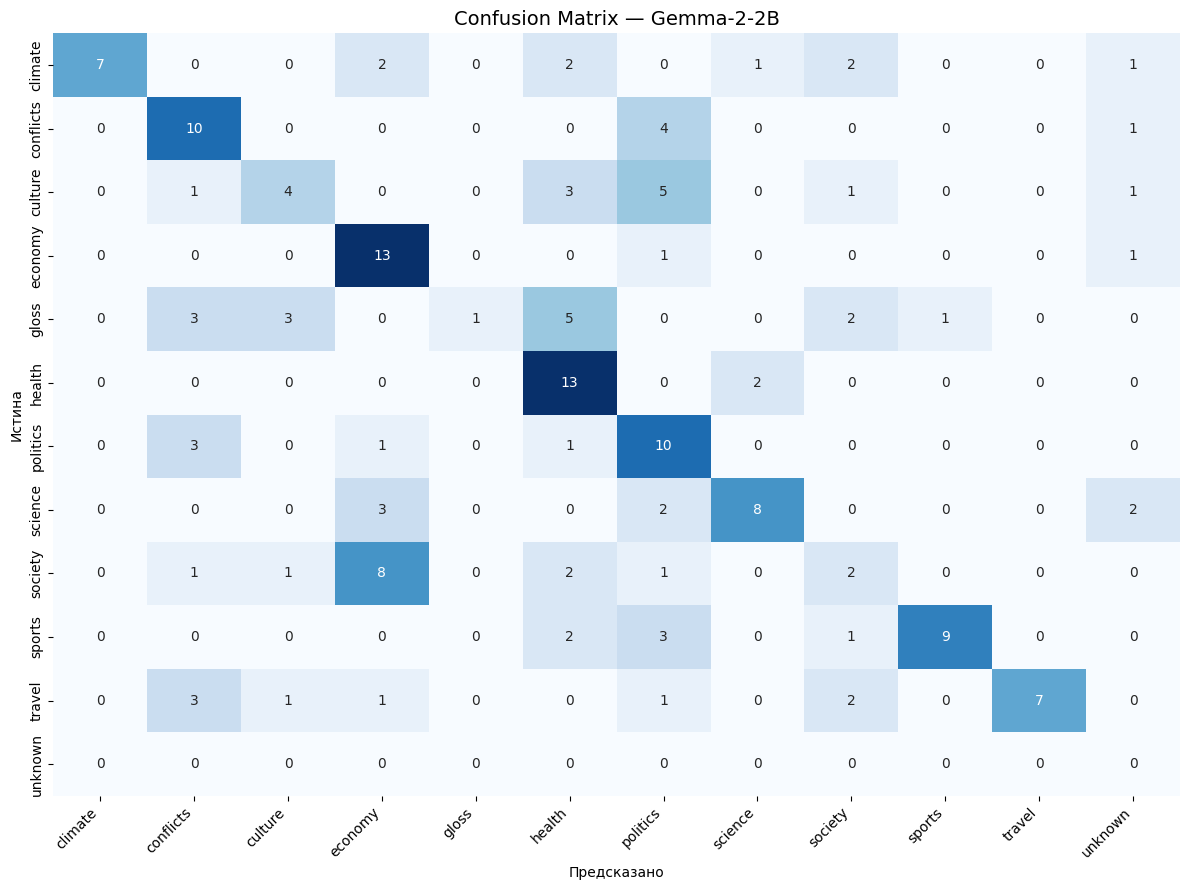


Топ-5 наиболее частых ошибок (true → predicted):
  society      → economy     : 8 раз
  culture      → politics    : 5 раз
  gloss        → health      : 5 раз
  conflicts    → politics    : 4 раз
  culture      → health      : 3 раз

Примеры текстов для ошибки "society" → "economy":

  Наиболее популярной косметической процедурой в США во время пандемии коронавируса стало увеличение ягодиц. Об этом пишет Bloomberg со ссылкой на отчет Американского Общества пластических хирургов. Все...

  В августе 2022 года самая дешевая недвижимость на первичном рынке в Подмосковье продавалась за 3,7 миллиона рублей. Об этом говорится в исследовании «Агентства инвестиций в недвижимость Москвы», котор...


In [33]:
# Используем результаты Gemma из основного инференса
gemma_preds = results['Gemma-2-2B']['pred_labels']

# Confusion matrix
pred_clean = [p if p in LABEL_NAMES else 'unknown' for p in gemma_preds]
has_unknown = 'unknown' in pred_clean
labels_plot = LABEL_NAMES + (['unknown'] if has_unknown else [])

cm = confusion_matrix(true_labels, pred_clean, labels=labels_plot)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels_plot, yticklabels=labels_plot,
            cmap='Blues', cbar=False)
plt.title('Confusion Matrix — Gemma-2-2B', fontsize=14)
plt.xlabel('Предсказано')
plt.ylabel('Истина')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('exp3_confusion_matrix.png', dpi=150)
plt.show()

# Топ-5 ошибок
from collections import Counter

errors = [(t, p) for t, p in zip(true_labels, pred_clean) if t != p]
top_errors = Counter(errors).most_common(5)

print('\nТоп-5 наиболее частых ошибок (true → predicted):')
for (true, pred), cnt in top_errors:
    print(f'  {true:12} → {pred:12}: {cnt} раз')

# Примеры текстов для топовой ошибки
print(f'\nПримеры текстов для ошибки "{top_errors[0][0][0]}" → "{top_errors[0][0][1]}":')
top_true, top_pred = top_errors[0][0]
examples = [(t, tl, pl) for t, tl, pl in zip(texts, true_labels, pred_clean)
            if tl == top_true and pl == top_pred]
for text, _, _ in examples[:2]:
    print(f'\n  {text[:200]}...')

### A/B тестирование форматов промптов

C (строгий): 100%|██████████| 165/165 [01:23<00:00,  1.99it/s]

              accuracy  f1_macro  unknown_rate
A (baseline)    0.5091    0.4970        0.0364
B (краткий)     0.4242    0.4000        0.0485
C (строгий)     0.4424    0.4141        0.0061


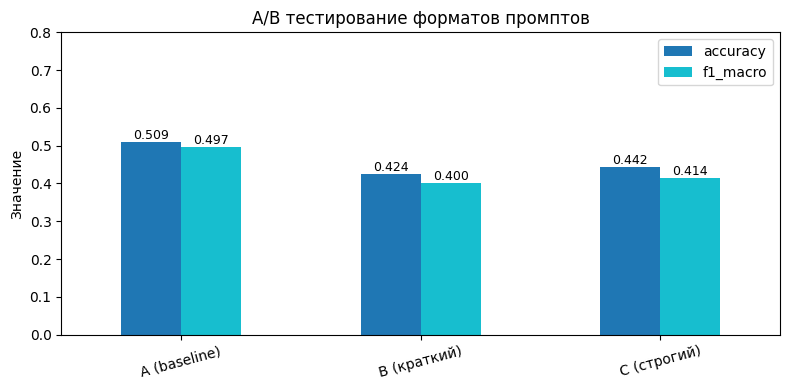

In [34]:
PROMPT_VARIANTS = {
    'A (baseline)': (
        'Ты классификатор новостей. '
        'Твоя задача - определить категорию новости. '
        f'Доступные категории: {CATEGORIES}. '
        'Ответь строго одним словом - только название категории на английском языке, без пояснений.'
    ),
    'B (краткий)': (
        f'Категория новости (одно слово на английском из списка): {CATEGORIES}.'
    ),
    'C (строгий)': (
        'Определи категорию новости. '
        f'Допустимые ответы ТОЛЬКО: {CATEGORIES}. '
        'Выведи ровно одно слово из этого списка. Любой другой вывод недопустим.'
    ),
}

exp4_results = {}

for variant_name, system_prompt in PROMPT_VARIANTS.items():
    preds = []
    for text in tqdm(texts, desc=variant_name):
        user_content = f'Новость: {text[:1000]}'
        messages = [{'role': 'user', 'content': f'{system_prompt}\n\n{user_content}'}]
        prompt = gemma_tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        response = generate(gemma_model, gemma_tokenizer, prompt=prompt, max_tokens=10, verbose=False)
        preds.append(parse_label(response))

    m = classification_metrics(true_labels, preds)
    m['unknown_rate'] = preds.count('unknown') / len(preds)
    exp4_results[variant_name] = m

df_exp4 = pd.DataFrame(exp4_results).T[['accuracy', 'f1_macro', 'unknown_rate']].round(4)
print(df_exp4)

df_exp4[['accuracy', 'f1_macro']].plot(kind='bar', figsize=(8, 4), rot=15, colormap='tab10')
plt.title('A/B тестирование форматов промптов')
plt.ylim(0, 0.8)
plt.ylabel('Значение')
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', fontsize=9)
plt.tight_layout()
plt.savefig('exp4_prompt_ab.png', dpi=150)
plt.show()

### Влияние температуры генерации (0.0, 0.3, 1.0)

temp=1.0: 100%|██████████| 165/165 [01:23<00:00,  1.97it/s]

           accuracy  f1_macro  unknown_rate
temp=0.01    0.5091    0.4970        0.0364
temp=0.3     0.4848    0.4803        0.0545
temp=1.0     0.4667    0.4580        0.0667


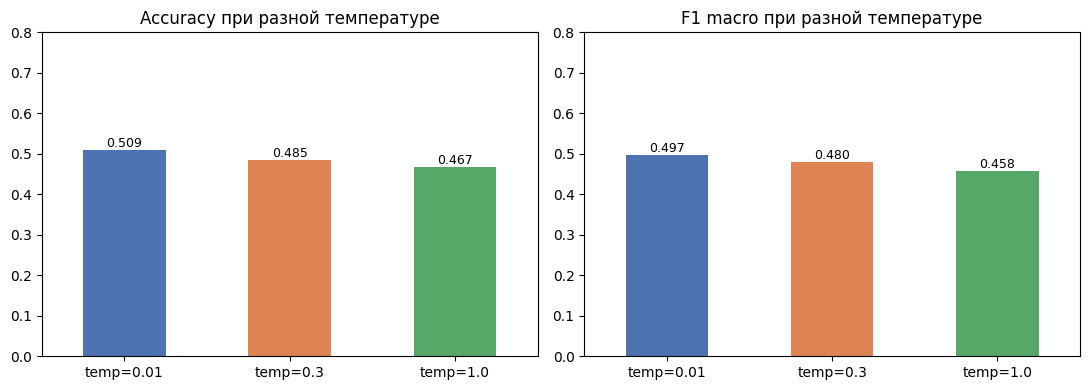

In [38]:
from mlx_lm.sample_utils import make_sampler

exp5_results = {}

for temp in [0.01, 0.3, 1.0]:
    preds = []
    for text in tqdm(texts, desc=f'temp={temp}'):
        prompt = build_prompt(gemma_tokenizer, gemma_supports_system, f'Новость: {text[:1000]}')
        response = generate(
            gemma_model, gemma_tokenizer,
            prompt=prompt,
            max_tokens=10,
            sampler=make_sampler(temp=temp),
            verbose=False,
        )
        preds.append(parse_label(response))

    m = classification_metrics(true_labels, preds)
    m['unknown_rate'] = preds.count('unknown') / len(preds)
    exp5_results[f'temp={temp}'] = m

df_exp5 = pd.DataFrame(exp5_results).T[['accuracy', 'f1_macro', 'unknown_rate']].round(4)
print(df_exp5)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(axes, ['accuracy', 'f1_macro'], ['Accuracy', 'F1 macro']):
    df_exp5[col].plot(kind='bar', ax=ax, rot=0, color=['#4C72B0', '#DD8452', '#55A868'])
    ax.set_title(f'{title} при разной температуре')
    ax.set_ylim(0, 0.8)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=9)
plt.tight_layout()
plt.savefig('exp5_temperature.png', dpi=150)
plt.show()

### Выводы по экспериментам

**1 Влияние длины промпта**
Подробный промпт с описанием каждой категории даёт прирост accuracy на ~10% (41.2% → 50.9%) по сравнению с кратким. Дополнительный контекст помогает модели однозначно интерпретировать семантически близкие классы, а unknown_rate снижается с 18.8% до 5.5%.

**2 Zero-shot vs Few-shot**
Few-shot не дал прироста качества - наоборот, ухудшил результат (0-shot: 49.7%, 5-shot: 44.2%). При этом скорость генерации упала с 1.94 до 1.12 it/s. Примеры помогают модели следовать формату ответа (unknown_rate у 1-shot минимален - 1.2%), но не улучшают саму классификацию.

**3 Анализ ошибок**
Наиболее частая ошибка - `society → economy` (8 раз). Это объясняется размытой границей между классами: новости о недвижимости, потребительских трендах сложно однозначно отнести к одной категории даже для человека. Также часто путаются `culture → politics` и `gloss → health`.

**4 A/B тестирование промптов**
Лучший результат показал baseline-промпт A (50.9%). Строгий промпт C минимизировал unknown_rate до 0.6%, но снизил accuracy до 44.2% - модель перестала отказываться от ответа, но стала чаще ошибаться с категорией. Краткий промпт B - худший по всем метрикам. Вывод: баланс между детальностью инструкции и свободой модели важнее жёсткого ограничения формата.

**5 Влияние температуры**
Обратная зависимость: temp=0.01 → 50.9%, temp=0.3 → 48.5%, temp=1.0 → 46.7%. Низкая температура повышает качество классификации. При высокой температуре растёт случайность и unknown_rate.

**6 Сравнение с BERT**
Не очень корректно сравнивать результат на разных датасетах с разным количество классов для классификации. Но с первого взгляда кажется что BERT-модели при том что на порядок меньше небольших LLM-моделей, дают сопоставимое качество. При этом они менее требовательны к ресурсам и их быстрее дообучить.

**7 Влияние степени квантизации**
В экспериментах участвовали две 4-bit'ные модели и одна 8-bit'ная. И худший результат показала 8-bit'ная (меньшая точность при максимальном времени ответа), что говорит о том, что степень квантизации может иметь далеко не самое важное значение. В первую очередь влияет архитектура модели.

**8 Длина ответа в токенах**
Максимальная длина у gemma и стабильная (3 токена) - сказывается отличие токенизатора SentencePiece от BPE, используемого в Qwen и SmolLM2. Не влияет на качество, но немного увеличивает время генерации.